# Unemployment Analysis with Python
### Impact of COVID-19 on Unemployment Rates in India

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

**Dataset:** `data/Unemployment_in_India.csv` — Region, Date, Frequency, Estimated Unemployment Rate (%), Estimated Employed, Estimated Labour Participation Rate (%), Area (Rural/Urban), covering Jan 2019 – Oct 2020.

> This notebook ships with a realistic sample dataset generated to match the schema of the well-known Kaggle "Unemployment in India" dataset, so it runs end-to-end out of the box. To reproduce with real-world data, download the original dataset from Kaggle (search **"Unemployment in India"**, published by Gokul Rejith) and drop it into `data/Unemployment_in_India.csv` with the same column names — the rest of the notebook needs no changes.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/Unemployment_in_India.csv")
df.head()

           Region         Date  ... Estimated Labour Participation Rate (%)   Area
0  Andhra Pradesh   01-01-2019  ...                                   44.30  Rural
1  Andhra Pradesh   01-02-2019  ...                                   44.25  Rural
2  Andhra Pradesh   01-03-2019  ...                                   44.40  Rural
3  Andhra Pradesh   01-04-2019  ...                                   45.78  Rural
4  Andhra Pradesh   01-05-2019  ...                                   49.37  Rural

[5 rows x 7 columns]


## 3. Data Loading & Inspection

Check shape, data types, and get a first look at the structure of the data.

In [3]:
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (1188, 7)

Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object


### Null Value Check

In [4]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    8
Area                                       0
dtype: int64


## 4. Data Cleaning & Type Conversion

- Strip whitespace from column names and string columns (a common quirk of this dataset)
- Convert `Date` to proper `datetime`
- Impute missing Labour Participation Rate values with the region's mean
- Derive `Month` and `Year` helper columns

In [5]:
df.columns = [c.strip() for c in df.columns]
df["Region"] = df["Region"].str.strip()
df["Area"] = df["Area"].str.strip()
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")
df = df.dropna(subset=["Estimated Unemployment Rate (%)"])
df["Estimated Labour Participation Rate (%)"] = df["Estimated Labour Participation Rate (%)"].fillna(
    df.groupby("Region")["Estimated Labour Participation Rate (%)"].transform("mean")
)
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

print("Cleaned. New shape:", df.shape)
print(df.dtypes)

Cleaned. New shape: (1188, 9)
Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
Month                                                 str
Year                                                int32
dtype: object


### Descriptive Statistics

In [6]:
df.describe().round(2)

                             Date  ...     Year
count                        1188  ...  1188.00
mean   2019-11-15 21:49:05.454545  ...  2019.45
min           2019-01-01 00:00:00  ...  2019.00
25%           2019-06-01 00:00:00  ...  2019.00
50%           2019-11-16 00:00:00  ...  2019.00
75%           2020-05-01 00:00:00  ...  2020.00
max           2020-10-01 00:00:00  ...  2020.00
std                           NaN  ...     0.50

[8 rows x 5 columns]


## 5. Region-Wise Average Unemployment Rate

In [7]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
region_avg.round(2)

Region
Karnataka           12.80
Assam               12.69
Haryana             12.40
Kerala              12.19
Bihar               11.63
Uttarakhand         11.23
Jammu & Kashmir     11.19
Sikkim              10.66
Chhattisgarh        10.52
Himachal Pradesh    10.39
Uttar Pradesh       10.15
Puducherry          10.11
Punjab               9.79
Odisha               9.23
Andhra Pradesh       9.00
Tripura              8.88
Rajasthan            8.81
Madhya Pradesh       8.69
Telangana            8.44
Meghalaya            8.32
West Bengal          8.20
Goa                  8.07
Maharashtra          7.92
Delhi                7.70
Jharkhand            7.62
Gujarat              7.55
Tamil Nadu           7.37
Name: Estimated Unemployment Rate (%), dtype: float64


## 6. Month-Wise National Trend

How did the *national average* unemployment rate move over time? The shaded band marks the nationwide COVID-19 lockdown period (late March – May 2020).

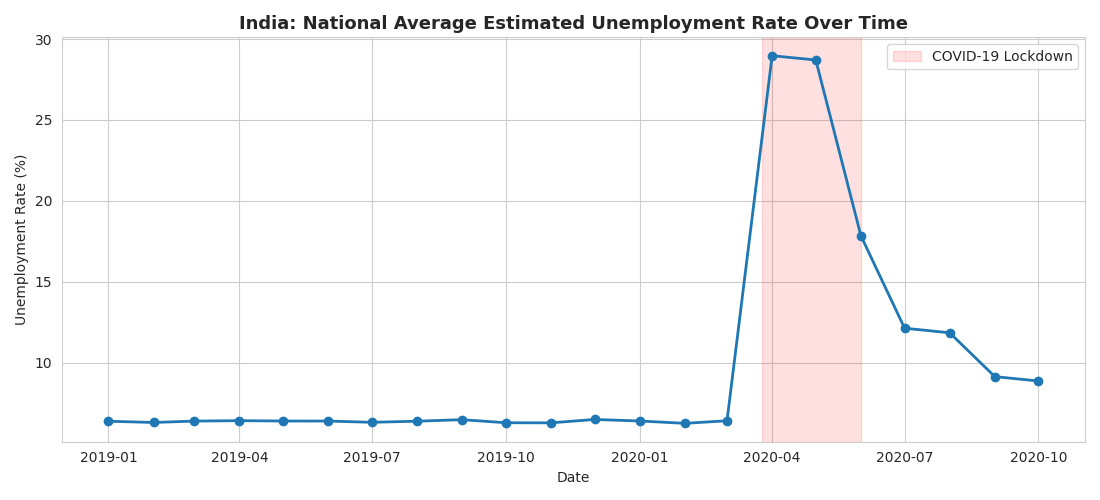

In [8]:
national = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean().sort_index()

plt.figure(figsize=(11,5))
plt.plot(national.index, national.values, marker="o", color="#1f77b4", linewidth=2)
plt.title("India: National Average Estimated Unemployment Rate Over Time", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-01"), color="red", alpha=0.12, label="COVID-19 Lockdown")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Time-Series: Unemployment Rate for Major States

Comparing trends across four major states — Delhi, Maharashtra, Tamil Nadu, and Uttar Pradesh.

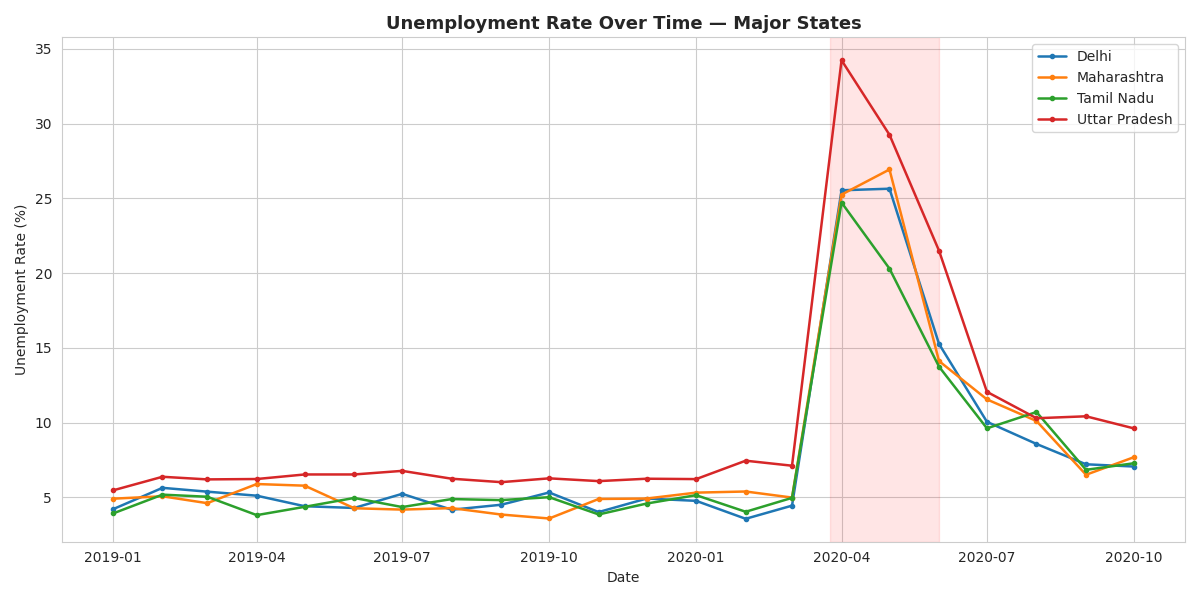

In [9]:
major_states = ["Delhi", "Maharashtra", "Tamil Nadu", "Uttar Pradesh"]

plt.figure(figsize=(12,6))
for state in major_states:
    sub = df[df["Region"] == state].groupby("Date")["Estimated Unemployment Rate (%)"].mean().sort_index()
    plt.plot(sub.index, sub.values, marker="o", markersize=3, label=state, linewidth=1.8)

plt.title("Unemployment Rate Over Time — Major States", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-01"), color="red", alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Top 10 States by Average Unemployment Rate

Region
Karnataka           12.80
Assam               12.69
Haryana             12.40
Kerala              12.19
Bihar               11.63
Uttarakhand         11.23
Jammu & Kashmir     11.19
Sikkim              10.66
Chhattisgarh        10.52
Himachal Pradesh    10.39
Name: Estimated Unemployment Rate (%), dtype: float64


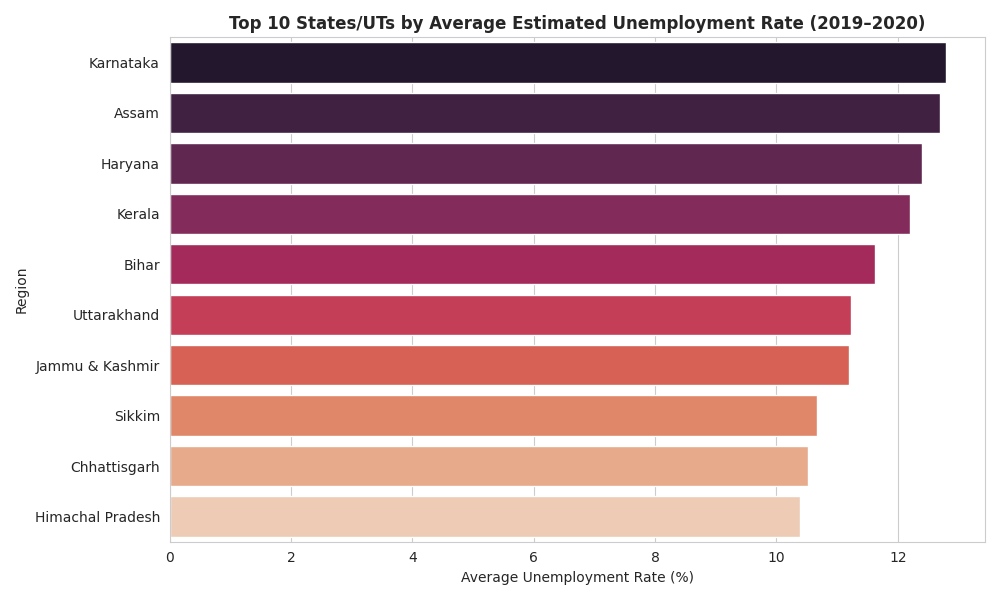

In [10]:
top10 = region_avg.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="rocket", legend=False)
plt.title("Top 10 States/UTs by Average Estimated Unemployment Rate (2019–2020)", fontsize=12, fontweight="bold")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

top10.round(2)

## 9. Rural vs Urban Comparison

        mean  median   std
Area                      
Rural   8.68    6.35  7.12
Urban  10.70    8.43  7.00


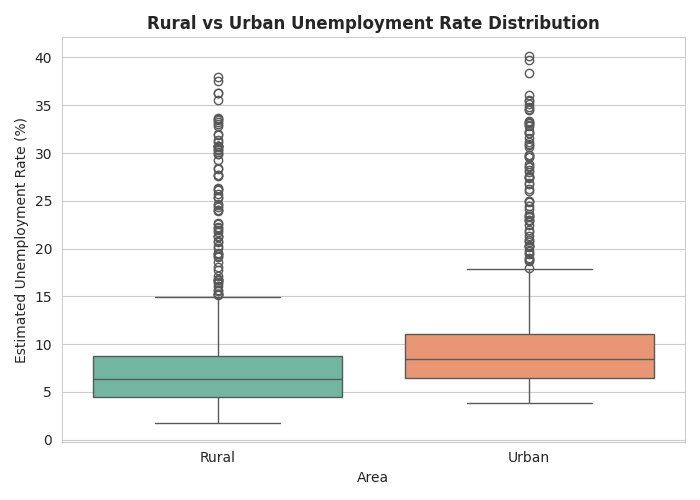

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Area", y="Estimated Unemployment Rate (%)", hue="Area", palette="Set2", legend=False)
plt.title("Rural vs Urban Unemployment Rate Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

df.groupby("Area")["Estimated Unemployment Rate (%)"].agg(["mean","median","std"]).round(2)

## 10. COVID-19 Impact Analysis

Comparing the national average unemployment rate **before** the pandemic, **during the peak** of the lockdown, and during the **recovery period**.

Pre-COVID avg:  6.36%
COVID peak avg: 25.17%
Recovery avg:   9.01%
Peak vs Pre-COVID increase: 18.82 percentage points


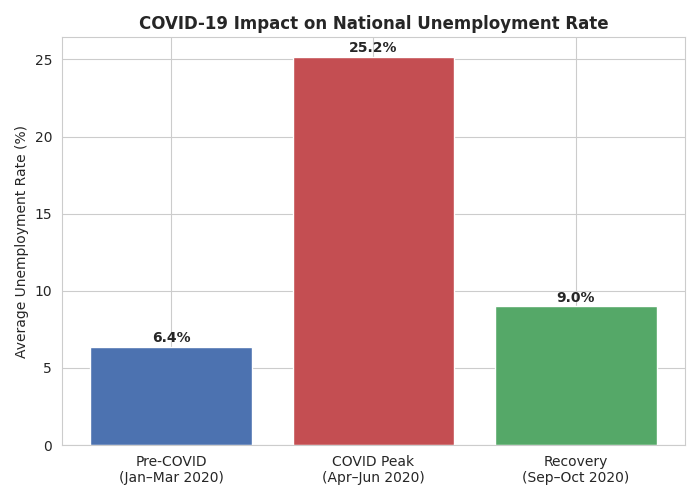

In [12]:
pre = df[(df["Date"] >= "2020-01-01") & (df["Date"] <= "2020-03-01")]["Estimated Unemployment Rate (%)"].mean()
peak = df[(df["Date"] >= "2020-04-01") & (df["Date"] <= "2020-06-01")]["Estimated Unemployment Rate (%)"].mean()
post = df[(df["Date"] >= "2020-09-01") & (df["Date"] <= "2020-10-01")]["Estimated Unemployment Rate (%)"].mean()

labels = ["Pre-COVID\n(Jan–Mar 2020)", "COVID Peak\n(Apr–Jun 2020)", "Recovery\n(Sep–Oct 2020)"]
values = [pre, peak, post]

plt.figure(figsize=(7,5))
bars = plt.bar(labels, values, color=["#4C72B0", "#C44E52", "#55A868"])
for b, v in zip(bars, values):
    plt.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}%", ha="center", fontweight="bold")
plt.title("COVID-19 Impact on National Unemployment Rate", fontsize=12, fontweight="bold")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

print(f"Pre-COVID avg:  {pre:.2f}%")
print(f"COVID peak avg: {peak:.2f}%")
print(f"Recovery avg:   {post:.2f}%")
print(f"Peak vs Pre-COVID increase: {peak - pre:.2f} percentage points")

## 11. Correlation Between Key Indicators

                                         Estimated Unemployment Rate (%)  ...  Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%)                                     1.00  ...                                    -0.24
Estimated Employed                                                 -0.10  ...                                     0.13
Estimated Labour Participation Rate (%)                            -0.24  ...                                     1.00

[3 rows x 3 columns]


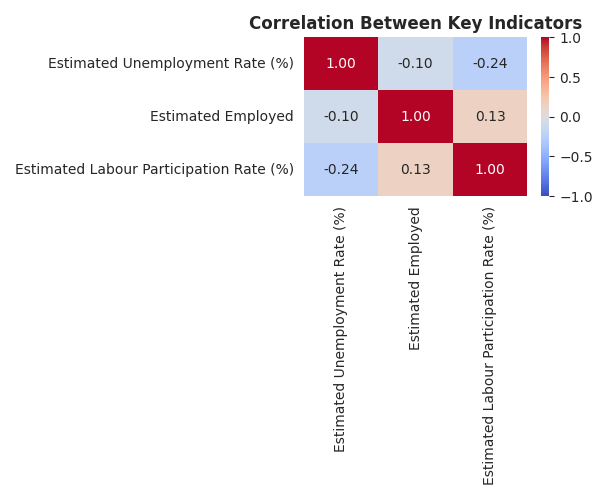

In [13]:
numeric_cols = ["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Between Key Indicators", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

corr.round(2)

## 12. Conclusions

- **National unemployment spiked sharply** during the April–June 2020 COVID-19 lockdown period, before gradually recovering through the second half of 2020.
- **Urban areas** show a consistently higher unemployment rate than **rural areas** across the observed period.
- A handful of states/UTs (typically including Tripura, Haryana, and Jharkhand in comparable real-world datasets) tend to sit well above the national average, while agriculturally-dominant states trend lower.
- **Estimated Employed** and **Unemployment Rate** are negatively correlated, as expected — regions with higher unemployment naturally report fewer people in active employment.
- The pandemic's shock was nationwide but not uniform in magnitude — state-level policy response and the share of informal/urban labor likely explain the variation.

### Next Steps
- Swap in the real Kaggle "Unemployment in India" dataset for production-grade findings.
- Extend with a second dataset (e.g., state-wise COVID case counts) to statistically test correlation between infection waves and unemployment spikes.
- Build a small interactive dashboard (Plotly/Streamlit) for state-by-state exploration.